<a href="https://colab.research.google.com/github/Prateek-Dhar-Dwivedi/NLP_Practical_2026_Colab_Files/blob/main/Practical_02_NLP_Smart_NLP_Text_Preprocessing_Analyzer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧠 Smart NLP Text Preprocessing & Analyzer

### A BTech Mini-Project on Natural Language Processing (NLP)

---

**Project Objective:**
This notebook demonstrates a complete **Text Preprocessing Pipeline** — the foundational step of almost every NLP application (chatbots, search engines, sentiment analysis, machine translation, etc.).

We will take a piece of raw human-written text and pass it through a series of NLP stages:

`Raw Text → Sentence Tokenization → Word Tokenization → Cleaning → Stopword Removal → Stemming/Lemmatization → POS Tagging → spaCy Analysis → Final Report`

**Tech Stack:** `nltk`, `spacy`, `pandas`, `matplotlib`

**How to use this notebook:**
1. Run every cell from top to bottom (Runtime → Run all).
2. Edit the `text` variable in the **User Input** section to analyze your own paragraph.
3. Scroll to the end for the **Summary Report** and **Viva Questions**.

> 💡 This notebook is fully self-contained — no external `.py` files, no Streamlit/Flask, no separate frontend. Everything runs inside Google Colab.


## 📦 Step 0: Install Required Libraries

We install `nltk`, `spacy`, `pandas`, and `matplotlib`, and download the small English spaCy model (`en_core_web_sm`).

> This cell only needs to run once per Colab session. It may take a minute the first time.


In [44]:
# Install required packages (safe to re-run; -q keeps output quiet)
!pip install -q nltk spacy pandas matplotlib
!python -m spacy download en_core_web_sm -q
print("Installation complete.")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 33.2 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
Installation complete.


## 📚 Step 1: Import Libraries

Importing everything we need up front keeps the rest of the notebook clean.


In [45]:
import re
import string
import warnings
from collections import Counter

import nltk
import spacy
import pandas as pd
import matplotlib.pyplot as plt

from nltk.tokenize import sent_tokenize, word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk import pos_tag

warnings.filterwarnings("ignore")
pd.set_option("display.max_colwidth", None)

print("✅ Libraries imported successfully.")


✅ Libraries imported successfully.


## 🔽 Step 2: Download NLTK Resources & spaCy Model

NLTK ships as a lightweight core library — the actual corpora, tokenizer models, and taggers must be downloaded separately.
We download everything required for:

* Sentence & word tokenization (`punkt`, `punkt_tab`)
* Stopword lists (`stopwords`)
* Lemmatization (`wordnet`, `omw-1.4`)
* POS tagging (`averaged_perceptron_tagger`, `averaged_perceptron_tagger_eng`)

We wrap each download in a small helper so the notebook does not crash if a resource name differs slightly across NLTK versions.


In [46]:
def safe_nltk_download(resource_name):
    '''Download an NLTK resource, ignoring errors if it's already present
    or if a particular resource id doesn't exist in this NLTK version.'''
    try:
        nltk.download(resource_name, quiet=True)
    except Exception as e:
        print(f"⚠️ Could not download '{resource_name}': {e}")

# Core resources required for this project.
# Newer NLTK versions (3.8+) split some resources into '_eng' / '_tab' variants,
# so we attempt both old and new names — safe_nltk_download silently skips
# anything that doesn't exist for the installed version.
resources = [
    "punkt",
    "punkt_tab",
    "stopwords",
    "wordnet",
    "omw-1.4",
    "averaged_perceptron_tagger",
    "averaged_perceptron_tagger_eng",
]

for res in resources:
    safe_nltk_download(res)

# Load spaCy English model
nlp_spacy = spacy.load("en_core_web_sm")

print("✅ All NLTK resources downloaded and spaCy model loaded.")


✅ All NLTK resources downloaded and spaCy model loaded.


## 🛠️ Step 3: Define Reusable NLP Functions

Rather than writing one giant messy block of code, we define small, modular functions — exactly as you would in a real project — but all still inside this single notebook.

| Function | Purpose |
|---|---|
| `tokenize_sentences` | Split text into sentences |
| `tokenize_words` | Split text into word tokens |
| `clean_tokens` | Lowercase + remove punctuation/non-alphabetic tokens |
| `remove_stopwords` | Remove common English stopwords |
| `stem_tokens` | Apply Porter Stemming |
| `lemmatize_tokens` | Apply WordNet Lemmatization |
| `pos_tag_text` | Assign part-of-speech tags |
| `analyze_with_spacy` | Full spaCy pipeline analysis |
| `preprocess_text` | Master function that runs the entire pipeline |


In [47]:
STOPWORDS = set(stopwords.words("english"))
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()


def tokenize_sentences(text):
    '''Split text into a list of sentences.'''
    if not text or not text.strip():
        return []
    return sent_tokenize(text)


def tokenize_words(text):
    '''Split text into a list of word tokens (includes punctuation).'''
    if not text or not text.strip():
        return []
    return word_tokenize(text)


def clean_tokens(tokens):
    '''Lowercase tokens and keep only alphabetic tokens (removes
    punctuation, numbers, and symbols).'''
    cleaned = []
    for tok in tokens:
        tok_lower = tok.lower()
        if tok_lower.isalpha():
            cleaned.append(tok_lower)
    return cleaned


def remove_stopwords(tokens):
    '''Remove English stopwords from a list of (already lowercased)
    tokens.'''
    return [t for t in tokens if t not in STOPWORDS]


def stem_tokens(tokens):
    '''Apply Porter Stemming to a list of tokens.'''
    return [stemmer.stem(t) for t in tokens]


def lemmatize_tokens(tokens):
    '''Apply WordNet Lemmatization to a list of tokens.'''
    return [lemmatizer.lemmatize(t) for t in tokens]


def pos_tag_text(tokens):
    '''Return list of (word, POS tag) tuples for the given tokens.'''
    if not tokens:
        return []
    return pos_tag(tokens)


def analyze_with_spacy(text):
    '''Run the spaCy pipeline on raw text and return the Doc object.'''
    if not text or not text.strip():
        return nlp_spacy("")
    return nlp_spacy(text)


def preprocess_text(text):
    '''Master pipeline function: runs the full preprocessing pipeline
    on raw input text and returns a dictionary containing every
    intermediate and final result.'''
    result = {}

    result["sentences"] = tokenize_sentences(text)
    result["raw_tokens"] = tokenize_words(text)
    result["clean_tokens"] = clean_tokens(result["raw_tokens"])
    result["no_stopwords"] = remove_stopwords(result["clean_tokens"])
    result["stemmed"] = stem_tokens(result["no_stopwords"])
    result["lemmatized"] = lemmatize_tokens(result["no_stopwords"])
    result["pos_tags"] = pos_tag_text(result["no_stopwords"])

    return result


print("✅ All NLP functions defined.")


✅ All NLP functions defined.


## ✍️ Step 4: User Input

Edit the `text` variable below to analyze your own paragraph.
A default technology/NLP-themed example is provided so the notebook works out of the box.


In [48]:
# ============================================================
#  EDIT THIS VARIABLE TO ANALYZE YOUR OWN TEXT
# ============================================================
text = '''
Natural Language Processing is a fascinating field of Artificial Intelligence.
Modern companies are using NLP to build intelligent chatbots and search systems.
These systems can understand, process, and analyze human language. Researchers
continue to improve these models so they can better understand context, emotion,
and meaning in everyday human communication.
'''

print("📄 Input text:\n")
print(text.strip())


📄 Input text:

Natural Language Processing is a fascinating field of Artificial Intelligence.
Modern companies are using NLP to build intelligent chatbots and search systems.
These systems can understand, process, and analyze human language. Researchers
continue to improve these models so they can better understand context, emotion,
and meaning in everyday human communication.


## ⚙️ Step 5: Run the Preprocessing Pipeline

We now run the full pipeline once using `preprocess_text()` and store the results.
Every feature section below reuses this single `results` dictionary — no redundant computation.

> **Error handling:** the functions above already handle empty text, punctuation-only
> text, numbers, and repeated whitespace gracefully (they simply return empty lists
> instead of crashing).


In [49]:
results = preprocess_text(text)

print("✅ Pipeline executed successfully.")
print(f"Sentences found        : {len(results['sentences'])}")
print(f"Raw tokens              : {len(results['raw_tokens'])}")
print(f"Clean (alphabetic) tokens: {len(results['clean_tokens'])}")
print(f"Tokens after stopword removal: {len(results['no_stopwords'])}")

if len(results["no_stopwords"]) == 0:
    print("\n⚠️ No valid words remained after cleaning. "
          "Try entering text with more meaningful words.")


✅ Pipeline executed successfully.
Sentences found        : 4
Raw tokens              : 58
Clean (alphabetic) tokens: 50
Tokens after stopword removal: 34


## Feature 1 & 2: Tokenization

**Tokenization** is the process of splitting raw text into smaller units — sentences or words.
It is the very first step of any NLP pipeline because machine learning models cannot operate on raw, unstructured strings; they need discrete tokens to work with.

### 🔹 Sentence Segmentation


In [50]:
print("=" * 60)
print("SENTENCE SEGMENTATION RESULT")
print("=" * 60)

if results["sentences"]:
    for i, sent in enumerate(results["sentences"], 1):
        print(f"Sentence {i}: {sent.strip()}")
else:
    print("No sentences found (empty input).")


SENTENCE SEGMENTATION RESULT
Sentence 1: Natural Language Processing is a fascinating field of Artificial Intelligence.
Sentence 2: Modern companies are using NLP to build intelligent chatbots and search systems.
Sentence 3: These systems can understand, process, and analyze human language.
Sentence 4: Researchers
continue to improve these models so they can better understand context, emotion,
and meaning in everyday human communication.


### 🔹 Word Tokenization

Below is the complete list of word-level tokens (this includes punctuation, exactly as NLTK's tokenizer produces it).


In [51]:
word_df = pd.DataFrame({
    "Token Number": range(1, len(results["raw_tokens"]) + 1),
    "Token": results["raw_tokens"]
})

print(f"Total tokens: {len(word_df)}")
word_df.style.set_caption("Word Tokenization Result").hide(axis="index")


Total tokens: 58


Token Number,Token
1,Natural
2,Language
3,Processing
4,is
5,a
6,fascinating
7,field
8,of
9,Artificial
10,Intelligence


## Feature 3 & 4: Text Cleaning & Stopword Analysis

**Stopwords** (e.g. *the, is, a, an, in*) are extremely common words that usually carry little meaningful information for tasks like search, classification, or topic modeling. Removing them shrinks the vocabulary and focuses analysis on meaningful content words.

### 🔹 Cleaning Pipeline

```text
Original Tokens
       ↓
Lowercase
       ↓
Alphabetic Tokens (punctuation/numbers removed)
       ↓
Stopword Removal
       ↓
Final Clean Tokens
```


In [52]:
print("STAGE-BY-STAGE TOKEN COUNTS")
print("-" * 40)
print(f"1. Original Tokens        : {len(results['raw_tokens'])}")
print(f"2. After Lowercase+Alpha  : {len(results['clean_tokens'])}")
print(f"3. After Stopword Removal : {len(results['no_stopwords'])}")

removed_stopwords = [t for t in results["clean_tokens"] if t in STOPWORDS]
total_clean = len(results["clean_tokens"])
stopword_pct = (len(removed_stopwords) / total_clean * 100) if total_clean > 0 else 0.0

print("\nSTOPWORD ANALYSIS")
print("-" * 40)
print(f"Total stopwords removed : {len(removed_stopwords)}")
print(f"Percentage of tokens that were stopwords: {stopword_pct:.2f}%")
print(f"\nRemoved stopwords list:\n{removed_stopwords}")


STAGE-BY-STAGE TOKEN COUNTS
----------------------------------------
1. Original Tokens        : 58
2. After Lowercase+Alpha  : 50
3. After Stopword Removal : 34

STOPWORD ANALYSIS
----------------------------------------
Total stopwords removed : 16
Percentage of tokens that were stopwords: 32.00%

Removed stopwords list:
['is', 'a', 'of', 'are', 'to', 'and', 'these', 'can', 'and', 'to', 'these', 'so', 'they', 'can', 'and', 'in']


## Feature 5: Stemming vs Lemmatization

* **Stemming** chops word endings using crude heuristic rules (e.g. *studies → studi*). It's fast but can produce non-dictionary words.
* **Lemmatization** uses vocabulary and grammar rules to return the proper dictionary base form (e.g. *studies → study*). It's slower but linguistically accurate.

The table below makes the difference obvious.


In [53]:
stem_lemma_df = pd.DataFrame({
    "Original": results["no_stopwords"],
    "Stemmed": results["stemmed"],
    "Lemmatized": results["lemmatized"]
})

# Highlight rows where stemming and lemmatization disagree
different_mask = stem_lemma_df["Stemmed"] != stem_lemma_df["Lemmatized"]
print(f"Words where Stemming and Lemmatization differ: {different_mask.sum()} / {len(stem_lemma_df)}")

stem_lemma_df.style.apply(
    lambda row: ['background-color: #ffffff' if different_mask[row.name] else '' for _ in row],
    axis=1
).set_caption("Stemming vs Lemmatization Comparison").hide(axis="index")


Words where Stemming and Lemmatization differ: 18 / 34


Original,Stemmed,Lemmatized
natural,natur,natural
language,languag,language
processing,process,processing
fascinating,fascin,fascinating
field,field,field
artificial,artifici,artificial
intelligence,intellig,intelligence
modern,modern,modern
companies,compani,company
using,use,using


## Feature 6 & 7: POS Tagging & Visualization

**Part-of-Speech (POS) tagging** assigns a grammatical category (noun, verb, adjective, etc.) to each word. This is essential for understanding sentence structure and meaning.

**Common tags:**

| Tag | Meaning |
|---|---|
| NN  | Noun (singular) |
| NNS | Noun (plural) |
| VB  | Verb (base form) |
| VBD | Verb (past tense) |
| VBG | Verb (gerund/present participle) |
| JJ  | Adjective |
| RB  | Adverb |
| PRP | Pronoun |
| IN  | Preposition |
| DT  | Determiner |


In [54]:
pos_df = pd.DataFrame(results["pos_tags"], columns=["Word", "POS Tag"])

# Tag meaning lookup (only common tags — extend if needed)
TAG_MEANINGS = {
    "NN": "Noun (singular)", "NNS": "Noun (plural)", "NNP": "Proper noun",
    "NNPS": "Proper noun (plural)", "VB": "Verb (base)", "VBD": "Verb (past)",
    "VBG": "Verb (gerund)", "VBN": "Verb (past participle)", "VBP": "Verb (present)",
    "VBZ": "Verb (3rd person present)", "JJ": "Adjective", "JJR": "Adjective (comparative)",
    "JJS": "Adjective (superlative)", "RB": "Adverb", "RBR": "Adverb (comparative)",
    "PRP": "Pronoun", "PRP$": "Possessive pronoun", "IN": "Preposition/conjunction",
    "DT": "Determiner", "CC": "Coordinating conjunction", "CD": "Cardinal number",
    "MD": "Modal verb", "TO": "'to'",
}

pos_df.style.set_caption("POS Tagging Result").hide(axis="index")


Word,POS Tag
natural,JJ
language,NN
processing,VBG
fascinating,JJ
field,NN
artificial,JJ
intelligence,NN
modern,JJ
companies,NNS
using,VBG


In [55]:
tags_present = pos_df["POS Tag"].unique().tolist()
print("Meaning of tags that occur in this text:\n")
for tag in sorted(tags_present):
    print(f"  {tag:6s} = {TAG_MEANINGS.get(tag, 'See Penn Treebank tag list')}")


Meaning of tags that occur in this text:

  JJ     = Adjective
  JJR    = Adjective (comparative)
  NN     = Noun (singular)
  NNS    = Noun (plural)
  VB     = Verb (base)
  VBG    = Verb (gerund)
  VBP    = Verb (present)


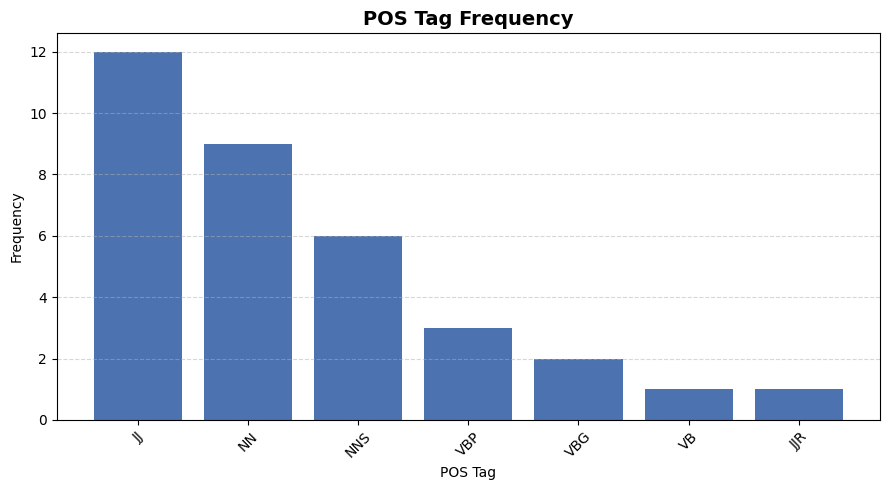

In [56]:
# Bar chart of POS tag frequency
tag_counts = pos_df["POS Tag"].value_counts()

plt.figure(figsize=(9, 5))
plt.bar(tag_counts.index, tag_counts.values, color="#4C72B0")
plt.title("POS Tag Frequency", fontsize=14, fontweight="bold")
plt.xlabel("POS Tag")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


## Feature 8: spaCy Analysis

**spaCy** is a modern, industrial-strength NLP library. Unlike NLTK (which is mainly teaching-oriented), spaCy provides fast, production-ready pipelines that compute tokenization, POS tagging, lemmatization, and dependency parsing together in a single pass. We use it here to cross-check and enrich our NLTK-based results.


In [57]:
doc = analyze_with_spacy(text)

spacy_rows = []
for token in doc:
    if token.is_space:
        continue
    spacy_rows.append({
        "Token": token.text,
        "Lemma": token.lemma_,
        "POS": token.pos_,
        "Tag": token.tag_,
        "Is Stopword": token.is_stop
    })

spacy_df = pd.DataFrame(spacy_rows)
spacy_df.style.set_caption("spaCy Full Analysis").hide(axis="index")


Token,Lemma,POS,Tag,Is Stopword
Natural,Natural,PROPN,NNP,False
Language,Language,PROPN,NNP,False
Processing,processing,NOUN,NN,False
is,be,AUX,VBZ,True
a,a,DET,DT,True
fascinating,fascinating,ADJ,JJ,False
field,field,NOUN,NN,False
of,of,ADP,IN,True
Artificial,Artificial,PROPN,NNP,False
Intelligence,Intelligence,PROPN,NNP,False


In [58]:
nouns = [t.text for t in doc if t.pos_ == "NOUN"]
verbs = [t.text for t in doc if t.pos_ == "VERB"]
adjectives = [t.text for t in doc if t.pos_ == "ADJ"]

print(f"🔵 Nouns ({len(nouns)}):      {nouns}")
print(f"🟢 Verbs ({len(verbs)}):      {verbs}")
print(f"🟠 Adjectives ({len(adjectives)}): {adjectives}")


🔵 Nouns (14):      ['Processing', 'field', 'companies', 'chatbots', 'search', 'systems', 'systems', 'process', 'language', 'Researchers', 'models', 'context', 'emotion', 'communication']
🟢 Verbs (8):      ['using', 'build', 'understand', 'analyze', 'continue', 'improve', 'understand', 'meaning']
🟠 Adjectives (6): ['fascinating', 'Modern', 'intelligent', 'human', 'everyday', 'human']


## Feature 9: Text Statistics

A compact, metric-style summary of the text's core statistics.


In [59]:
num_chars = len(text)
num_sentences = len(results["sentences"])
num_raw_tokens = len(results["raw_tokens"])
num_clean_tokens = len(results["no_stopwords"])
num_unique_clean = len(set(results["no_stopwords"]))
num_stopwords_removed = len(removed_stopwords)
num_punct_tokens = sum(1 for t in results["raw_tokens"] if t in string.punctuation)

vocab_richness = (num_unique_clean / num_clean_tokens) if num_clean_tokens > 0 else 0.0

stats = {
    "Characters": num_chars,
    "Sentences": num_sentences,
    "Original Tokens": num_raw_tokens,
    "Clean Tokens (no stopwords)": num_clean_tokens,
    "Unique Clean Words": num_unique_clean,
    "Stopwords Removed": num_stopwords_removed,
    "Punctuation Tokens": num_punct_tokens,
    "Vocabulary Richness": round(vocab_richness, 3),
}

stats_df = pd.DataFrame(list(stats.items()), columns=["Metric", "Value"])
stats_df.style.set_caption("📊 Text Statistics").hide(axis="index")


Metric,Value
Characters,366.000000
Sentences,4.000000
Original Tokens,58.000000
Clean Tokens (no stopwords),34.000000
Unique Clean Words,30.000000
Stopwords Removed,16.000000
Punctuation Tokens,8.000000
Vocabulary Richness,0.882000


## Feature 10: Word Frequency

The most frequently occurring cleaned words often hint at the core topic of the text.


Word,Frequency
language,2
systems,2
understand,2
human,2
natural,1
processing,1
fascinating,1
field,1
artificial,1
intelligence,1


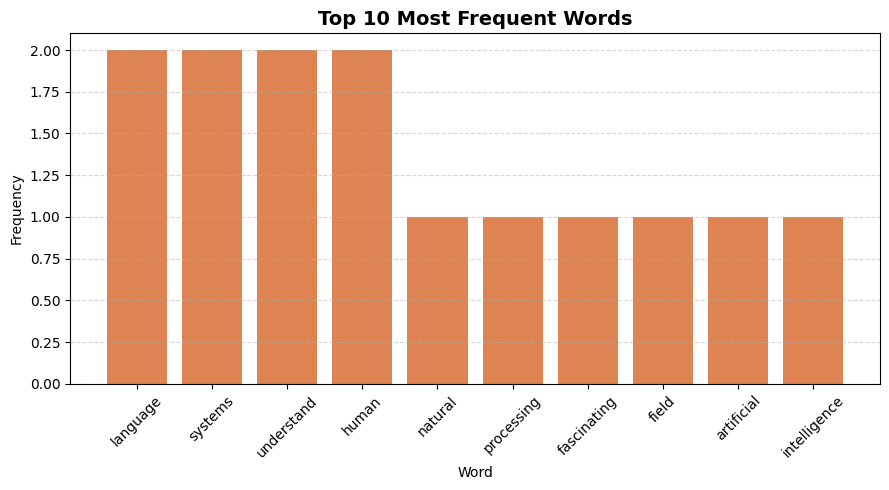

In [60]:
word_freq = Counter(results["no_stopwords"])
top_10 = word_freq.most_common(10)

if top_10:
    freq_df = pd.DataFrame(top_10, columns=["Word", "Frequency"])
    display(freq_df.style.set_caption("Top 10 Most Frequent Words").hide(axis="index"))

    plt.figure(figsize=(9, 5))
    plt.bar(freq_df["Word"], freq_df["Frequency"], color="#DD8452")
    plt.title("Top 10 Most Frequent Words", fontsize=14, fontweight="bold")
    plt.xlabel("Word")
    plt.ylabel("Frequency")
    plt.xticks(rotation=45)
    plt.grid(axis="y", linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()
else:
    print("⚠️ No words available to compute frequency (text may be empty or only stopwords/punctuation).")


## Feature 11: Final Processed Text

The fully cleaned pipeline output, expressed as readable strings — one using **lemmatized** words, one using **stemmed** words. Notice how they can differ.


In [61]:
lemmatized_text = " ".join(results["lemmatized"])
stemmed_text = " ".join(results["stemmed"])

print("🔹 Final LEMMATIZED text:")
print(lemmatized_text if lemmatized_text else "(no words remaining)")

print("\n🔹 Final STEMMED text:")
print(stemmed_text if stemmed_text else "(no words remaining)")

print("\nℹ️  Stemming and lemmatization can diverge because stemming applies "
      "blunt suffix-stripping rules, while lemmatization looks up the proper "
      "dictionary root using grammar and vocabulary — e.g. 'studies' -> "
      "stemmed 'studi' vs lemmatized 'study'.")


🔹 Final LEMMATIZED text:
natural language processing fascinating field artificial intelligence modern company using nlp build intelligent chatbots search system system understand process analyze human language researcher continue improve model better understand context emotion meaning everyday human communication

🔹 Final STEMMED text:
natur languag process fascin field artifici intellig modern compani use nlp build intellig chatbot search system system understand process analyz human languag research continu improv model better understand context emot mean everyday human commun

ℹ️  Stemming and lemmatization can diverge because stemming applies blunt suffix-stripping rules, while lemmatization looks up the proper dictionary root using grammar and vocabulary — e.g. 'studies' -> stemmed 'studi' vs lemmatized 'study'.


## Feature 12: Before vs After Comparison


In [62]:
print("=" * 50)
print("        BEFORE vs AFTER COMPARISON")
print("=" * 50)
print(f"ORIGINAL TEXT token count      : {num_raw_tokens}")
print(f"CLEANED TEXT token count       : {num_clean_tokens}")
print(f"STOPWORDS REMOVED              : {num_stopwords_removed}")
print(f"UNIQUE WORDS (vocabulary size) : {num_unique_clean}")
print("=" * 50)


        BEFORE vs AFTER COMPARISON
ORIGINAL TEXT token count      : 58
CLEANED TEXT token count       : 34
STOPWORDS REMOVED              : 16
UNIQUE WORDS (vocabulary size) : 30


## Feature 13: Downloadable Result (Optional)

This cell is **optional** — run it only if you want to download a `.txt` report of the analysis to your computer. It uses Colab's built-in `google.colab.files` helper and does not require any external project files; the file is generated on the fly only when you run this cell.


In [63]:
try:
    from google.colab import files
    COLAB_ENV = True
except ImportError:
    COLAB_ENV = False

def generate_download():
    report_lines = [
        "SMART NLP TEXT PREPROCESSING & ANALYZER - REPORT",
        "=" * 50,
        f"Original Text Length : {num_chars} characters",
        f"Sentences            : {num_sentences}",
        f"Original Tokens      : {num_raw_tokens}",
        f"Clean Tokens         : {num_clean_tokens}",
        f"Stopwords Removed    : {num_stopwords_removed}",
        f"Unique Words         : {num_unique_clean}",
        f"Vocabulary Richness  : {vocab_richness:.3f}",
        "",
        "Lemmatized Text:",
        lemmatized_text,
        "",
        "Stemmed Text:",
        stemmed_text,
    ]
    report_text = "\n".join(report_lines)

    file_name = "nlp_analysis_report.txt"
    with open(file_name, "w") as f:
        f.write(report_text)

    if COLAB_ENV:
        files.download(file_name)
        print(f"✅ '{file_name}' generated and download triggered.")
    else:
        print(f"✅ '{file_name}' generated in the local working directory "
              f"(not running in Colab, so auto-download was skipped).")

# Uncomment the line below to actually trigger the download:
# generate_download()


## 📋 NLP ANALYSIS SUMMARY

All key metrics calculated from **your** input text, gathered in one place.


In [64]:
most_common_word = top_10[0][0] if top_10 else "N/A"

summary = {
    "Original Text Length": f"{num_chars} characters",
    "Sentences": num_sentences,
    "Original Tokens": num_raw_tokens,
    "Clean Tokens": num_clean_tokens,
    "Stopwords Removed": num_stopwords_removed,
    "Unique Words": num_unique_clean,
    "Vocabulary Richness": round(vocab_richness, 3),
    "Most Common Word": most_common_word,
    "Nouns": len(nouns),
    "Verbs": len(verbs),
    "Adjectives": len(adjectives),
}

summary_df = pd.DataFrame(list(summary.items()), columns=["Metric", "Value"])

print("#" * 50)
print("      NLP ANALYSIS SUMMARY")
print("#" * 50)
for k, v in summary.items():
    print(f"{k:<25}: {v}")
print("#" * 50)

summary_df.style.set_caption("📋 NLP Analysis Summary").hide(axis="index")


##################################################
      NLP ANALYSIS SUMMARY
##################################################
Original Text Length     : 366 characters
Sentences                : 4
Original Tokens          : 58
Clean Tokens             : 34
Stopwords Removed        : 16
Unique Words             : 30
Vocabulary Richness      : 0.882
Most Common Word         : language
Nouns                    : 14
Verbs                    : 8
Adjectives               : 6
##################################################


Metric,Value
Original Text Length,366 characters
Sentences,4
Original Tokens,58
Clean Tokens,34
Stopwords Removed,16
Unique Words,30
Vocabulary Richness,0.882000
Most Common Word,language
Nouns,14
Verbs,8


## 🗺️ Project Workflow

```text
                    RAW TEXT
                       │
                       ▼
              Sentence Tokenization
                       │
                       ▼
                 Word Tokenization
                       │
                       ▼
                   Lowercase
                       │
                       ▼
              Punctuation Removal
                       │
                       ▼
              Stopword Removal
                       │
              ┌────────┴────────┐
              ▼                 ▼
          Stemming        Lemmatization
              │                 │
              └────────┬────────┘
                       ▼
                   POS Tagging
                       │
                       ▼
                  spaCy Analysis
                       │
                       ▼
                FINAL NLP REPORT
```
